In [54]:
import matplotlib.pyplot as plt
import numpy as np
from nskernel import NonStationaryKernel
from scipy.optimize import fmin_l_bfgs_b, curve_fit
from spleaf import cov, term
import scipy.io as sp
import emcee

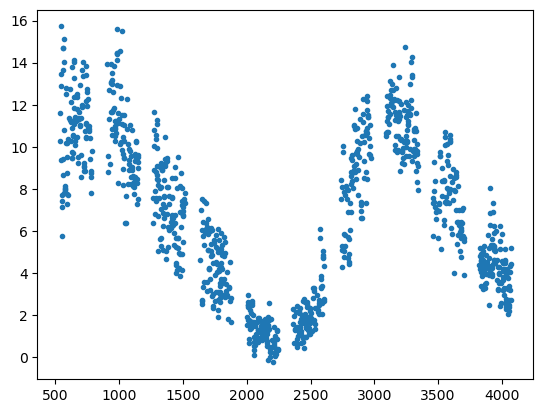

In [55]:
realis = 2
use_file = f"serie_res_bt_G2_1000_4m_NOISE0.09_OGS_MAG_M1_real{realis}.sav"
data = sp.readsav(use_file)

arr_len = len(data['tt'])
tt = data['tt']
rv = data['rv']
rhk = data['ca']

erv = np.zeros(len(tt))+0.05
rhk_err = np.zeros(len(tt))+5e-4


T = [tt,tt]
Y = [rv,rhk]
Yerr = [erv,rhk_err]

t_full, y_full, yerr_full, series_index = cov.merge_series(T,Y,Yerr)

plt.plot(tt, rv, ".")

In [56]:
def alpha(t, pcyc, phi, k, c):
    # constraint |k| <= 1/3
    # k = (1.0 / 3.0) * np.tanh(k_raw)
    x = (2.0 * np.pi / pcyc) * t + phi

    fc = np.sin(x + k * np.sin(x))  # in [-1, 1]

    # linear normalization to [C, 1]
    return ((1.0 - c) / 2.0) * (fc + 1.0) + c

def alpha_grad(t, pcyc, phi, k, c):
    
    omega = 2.0 * np.pi / pcyc
    x = omega * t + phi

    # k is provided directly (assumed already constrained to |k| <= 1/3)
    # (previously: k = (1.0 / 3.0) * np.tanh(k_raw))

    inner = x + k * np.sin(x)
    s_inner = np.sin(inner)
    c_inner = np.cos(inner)

    scale = (1.0 - c) / 2.0

    # d(inner)/dx
    d_inner_dx = 1.0 + k * np.cos(x)

    # d alpha / d s
    d_alpha_ds = scale

    # chain: d alpha / d inner
    d_alpha_dinner = d_alpha_ds * c_inner

    grads = {}

    # ----- derivative wrt phi -----
    # dx/dphi = 1
    grads['phi'] = d_alpha_dinner * d_inner_dx

    # ----- derivative wrt pcyc -----
    # omega = 2π/pcyc
    domega_dp = -2.0 * np.pi / (pcyc ** 2)
    dx_dp = domega_dp * t
    grads['pcyc'] = d_alpha_dinner * d_inner_dx * dx_dp

    # ----- derivative wrt k -----
    # k is the input directly, so dk/dk = 1
    d_inner_dk = np.sin(x)
    grads['k'] = d_alpha_dinner * d_inner_dk

    # ----- derivative wrt c -----
    # alpha = scale*(s+1) + c
    # scale = (1-C)/2
    # d alpha / dC = -(1/2)*(s+1) + 1
    grads['c'] = -0.5 * (s_inner + 1.0) + 1.0

    return grads


In [57]:
class MultiSeriesKernel(term.MultiSeriesKernel):
  def _grad_param(self, grad_dU=None, grad_dV=None):
    if grad_dU is not None or grad_dV is not None:
      raise NotImplementedError()
    return super()._grad_param()

In [58]:
stds = [np.std(y) for y in Y]
sig = 1.0
prot = 20.0
Q = 1.0


rvjit = 0.2
rhkjit = 0.1


pcyc, phi, k, c = 2500.0, np.pi/10, 0.2, 0.05


C = cov.Cov(
  t_full,
  err=term.Error(yerr_full),
  rv_jit=term.InstrumentJitter(series_index[0], rvjit),
  rhk_jit=term.InstrumentJitter(series_index[1], rhkjit),
  gp=term.SimpleProductKernel(
      nonstat=NonStationaryKernel(alpha, alpha_grad, pcyc=pcyc, phi = phi, k = k, c = c),
      rot = MultiSeriesKernel(term.SHOKernel(sig,prot, Q), series_index, 
        [4.15643126e-01, 4.01317041e-01], 
        np.array([1.69879254e-02, 0.0])
    ),
  )
)


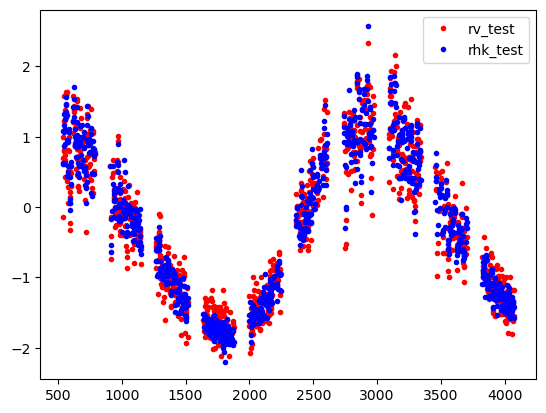

In [61]:
fc_norm = alpha(t_full[series_index[0]], pcyc, phi, k, c)
fc_unnorm = (fc_norm - c) / ((1.0 - c) / 2.0) - 1
drawn_sample = C.sample()
drawn_sample_rv = drawn_sample[series_index[0]]
drawn_sample_rhk = drawn_sample[series_index[1]]

params_test = [1.44387211e+00, 1.50593855e+00, -2.86247045e-01, -2.92056157e-01]

rv_test = drawn_sample_rv + fc_unnorm*params_test[-4] + params_test[-2]
rhk_test = drawn_sample_rhk + fc_unnorm*params_test[-3] + params_test[-1]


plt.figure()
plt.plot(t_full[series_index[0]], rv_test, ".", color="red", label="rv_test")
plt.plot(t_full[series_index[1]], rhk_test, ".", color="blue", label="rhk_test")
plt.legend()


In [62]:
Y = [rv_test,rhk_test]

t_full, y_full, yerr_full, series_index = cov.merge_series(T,Y,Yerr)


In [63]:
rvjit_max = 0.4
rhkjit_max = 0.4

prot_min = 18.0
prot_max = 22.0
Q_min = 0.7
Q_max = 1.3

pcyc_min = 2000.0
pcyc_max = 3000.0

alpha_0_max = 0.7
alpha_1_max = 0.7
beta_0_max  = 0.007

gamma_0_max = 2.0
gamma_1_max = 2.0

delta_0_min = -4.0
delta_0_max = 4.0
delta_1_min = -4.0
delta_1_max = 4.0

bounds_list = [
    (0.0, rvjit_max),                     # rv_jit.sig
    (0.0, rhkjit_max),                     # rhk_jit.sig
    (pcyc_min, pcyc_max),  
    (-np.pi,np.pi),
    (-0.4,0.4),
    (0.005,0.2),
    # (-10,10),
    
    (prot_min, prot_max),                 # rot.P0 (period)
    (Q_min, Q_max),                      # rot.Q (quality factor)
    (0, alpha_0_max),         # rot.alpha_0 (set lower bound to zero)
    (-alpha_1_max, alpha_1_max),         # rot.alpha_1
    (-beta_0_max, beta_0_max),         # rot.beta_0

    (0.0, gamma_0_max),         # rot.gamma_0
    (0.0, gamma_1_max),         # rot.gamma_1
    (delta_0_min, delta_0_max),         # delta_0 (offset for series 0)
    (delta_1_min, delta_1_max),         # delta_1 (offset for series 1)
]

C.param


['rv_jit.sig',
 'rhk_jit.sig',
 'gp.nonstat_pcyc',
 'gp.nonstat_phi',
 'gp.nonstat_k',
 'gp.nonstat_c',
 'gp.rot_sig',
 'gp.rot_P0',
 'gp.rot_Q',
 'gp.rot_alpha_0',
 'gp.rot_alpha_1',
 'gp.rot_beta_0',
 'gp.rot_beta_1']

In [64]:
fitted = [k for k, key in enumerate(C.param) if key != 'gp.rot_sig' and key != "gp.rot_beta_1"]  
params = [C.param[k] for k in fitted]
x0 = C.get_param(params)

x0 = np.append(x0,[1.0,1.0,-0.2,-0.2])

def negloglike(x, y, C):
  
  C.set_param(x[:len(params)], params)
  fc = alpha(t_full, x[2],x[3],x[4],x[5])
  fc_unnorm = (fc - x[5]) / ((1.0 - x[5]) / 2.0) - 1
  y_model = y.copy()
  y_model[series_index[0]] -= (x[-4]*fc_unnorm[series_index[0]] + x[-2])
  y_model[series_index[1]] -= (x[-3]*fc_unnorm[series_index[1]] + x[-1])
  nll = -C.loglike(y_model)
  # gradient
  lg = C.loglike_grad()
  dL_dy = np.asarray(lg[0]).reshape(-1)      # shape (N_total,) 
  dL_dparams = np.asarray(lg[1]).reshape(-1) # shape (12,)      

  base_grad = - dL_dparams[fitted]  

  # gradients wrt gamma (scale of fc)
  grad_gamma_0 = np.sum(dL_dy[series_index[0]] * fc_unnorm[series_index[0]])
  grad_gamma_1 = np.sum(dL_dy[series_index[1]] * fc_unnorm[series_index[1]])
  # gradients wrt delta (additive offsets)
  grad_delta_0 = np.sum(dL_dy[series_index[0]])
  grad_delta_1 = np.sum(dL_dy[series_index[1]])

  nll_grad = np.concatenate([np.asarray(base_grad).ravel(), np.array([grad_gamma_0, grad_gamma_1, grad_delta_0, grad_delta_1])])


  # nll_grad = -C.loglike_grad()[1][fitted]

  return (nll, nll_grad)


result = fmin_l_bfgs_b(negloglike, x0, args=(y_full, C), bounds=bounds_list)
xbest = result[0]

C.set_param(xbest[:len(params)], params)
C.set_param([1.0, 0.0], ['gp.rot_sig','gp.rot_beta_1'])

print(params)
print(xbest)

['rv_jit.sig', 'rhk_jit.sig', 'gp.nonstat_pcyc', 'gp.nonstat_phi', 'gp.nonstat_k', 'gp.nonstat_c', 'gp.rot_P0', 'gp.rot_Q', 'gp.rot_alpha_0', 'gp.rot_alpha_1', 'gp.rot_beta_0']
[ 1.96539195e-01  1.02984835e-01  2.50009270e+03  4.23209075e-01
  2.24714098e-01  5.24033327e-02  2.01220165e+01  7.19733939e-01
  5.45981716e-01  5.10982836e-01  7.00000000e-03  1.35604902e+00
  1.41332069e+00 -3.50967194e-01 -3.56154248e-01]


In [65]:
def log_prior(theta):
    # unpack theta (added delta_0, delta_1 as final two entries)
    # rv_jit, rhk_jit, pcyc, phi, k_raw, c, rot_P0, rot_Q, rot_alpha_0, rot_alpha_1, rot_beta_0, gamma_0, gamma_1, delta_0, delta_1 = theta
    rv_jit, rhk_jit, pcyc, phi, k, c, rot_P0, rot_Q, rot_alpha_0, rot_alpha_1, rot_beta_0, gamma_0, gamma_1, delta_0, delta_1 = theta
    phi = phi % (2*np.pi)
    if 0.0 < rv_jit < rvjit_max and 0.0 < rhk_jit < rhkjit_max and pcyc_min < pcyc < pcyc_max and -np.pi < phi < np.pi and -0.4< k < 0.4 and 0.005 < c < 0.5 and prot_min < rot_P0 < prot_max and Q_min < rot_Q < Q_max and 0.0 < rot_alpha_0 < alpha_0_max and -alpha_1_max < rot_alpha_1 < alpha_1_max and -beta_0_max < rot_beta_0 < beta_0_max and 0.0 < gamma_0 < gamma_0_max and 0.0 < gamma_1 < gamma_1_max and delta_0_min < delta_0 < delta_0_max and delta_1_min < delta_1 < delta_1_max:
        return 0.0
    return -np.inf

def log_probability(theta, y, C):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + -1*negloglike(theta, y, C)[0]

x0 = xbest.copy()
print(x0)
print(log_prior(x0))    

# x0 = [0.03, 0.2, 1500.0, 0.015, 4.0, 4.0, 4.0]
ndim = len(x0)
pos = x0 + 1e-4 * np.random.randn(ndim*3, ndim)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(y_full, C)
)
sampler.run_mcmc(pos, 2000, progress=True);



[ 1.96539195e-01  1.02984835e-01  2.50009270e+03  4.23209075e-01
  2.24714098e-01  5.24033327e-02  2.01220165e+01  7.19733939e-01
  5.45981716e-01  5.10982836e-01  7.00000000e-03  1.35604902e+00
  1.41332069e+00 -3.50967194e-01 -3.56154248e-01]
-inf


  0%|          | 0/2000 [00:00<?, ?it/s]/opt/anaconda3/envs/sleaf/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 2000/2000 [00:58<00:00, 34.37it/s]


['rv_jit.sig', 'rhk_jit.sig', 'gp.nonstat_pcyc', 'gp.nonstat_phi', 'gp.nonstat_k', 'gp.nonstat_c', 'gp.rot_P0', 'gp.rot_Q', 'gp.rot_alpha_0', 'gp.rot_alpha_1', 'gp.rot_beta_0', 'gamma_0', 'gamma_1', 'delta_0', 'delta_1']


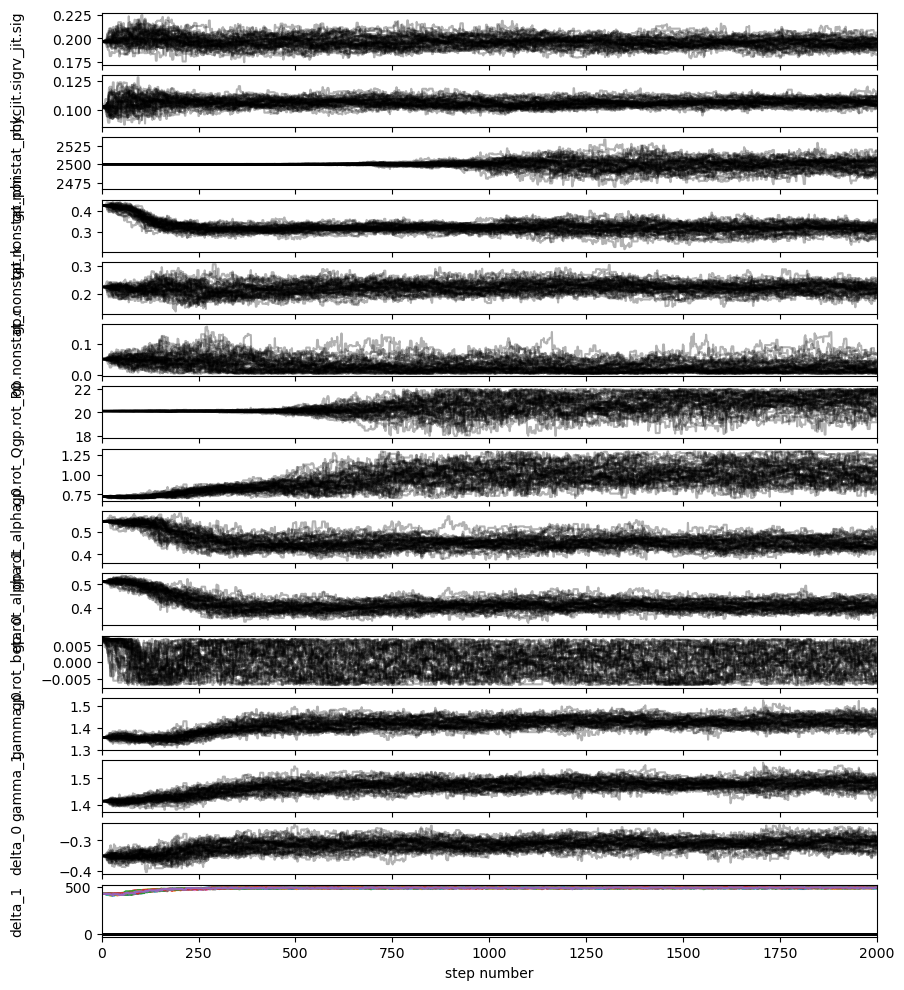

In [66]:
# ig, axes = plt.subplots(13, figsize=(10, 12), sharex=True)
ig, axes = plt.subplots(len(params) + 4, figsize=(10, 12), sharex=True)
samples = sampler.get_chain()

# labels = params + ['gamma_0', 'gamma_1', 'delta_0', 'delta_1']
labels = params + ['gamma_0', 'gamma_1', 'delta_0', 'delta_1']
print(labels)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

logp = sampler.get_log_prob(flat=False)
axes[-1].plot(logp)

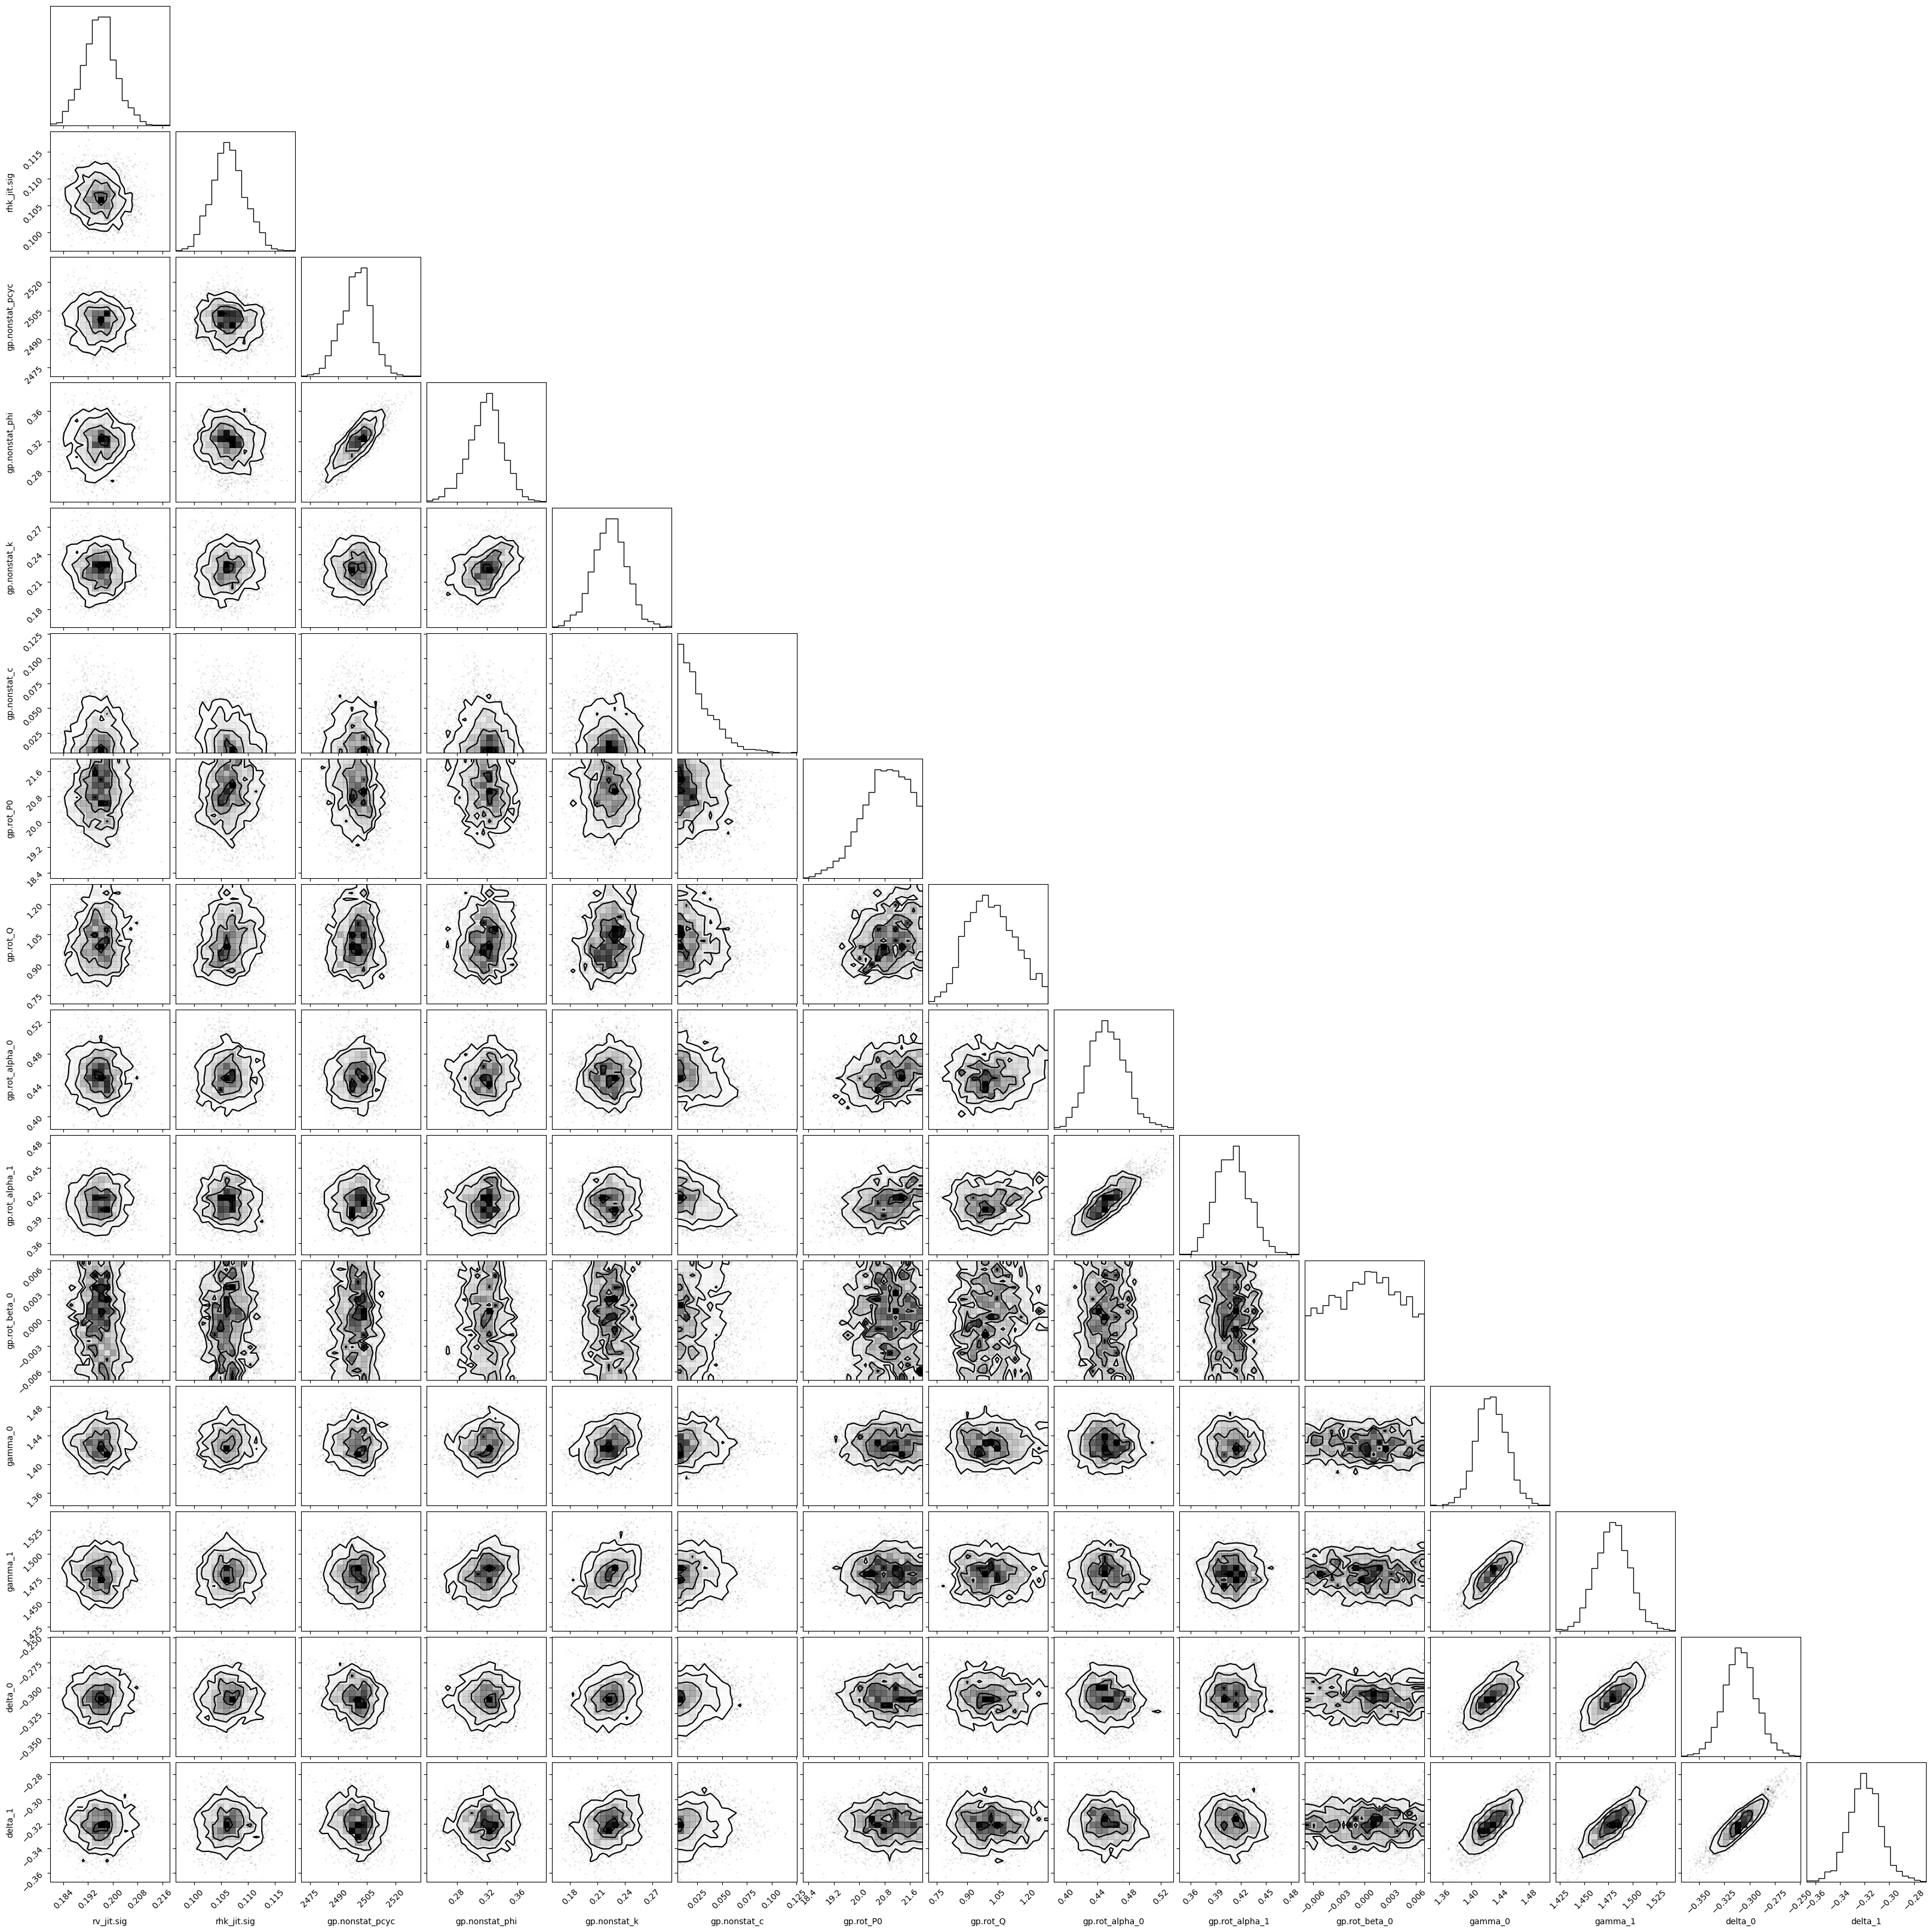

In [68]:
import corner

flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)

fig = corner.corner(
    flat_samples, labels=labels
);



In [69]:
burn = 1000   
thin = 1

flat_samples = sampler.get_chain(discard=burn, thin=thin, flat=True)   # shape (n_samples, ndim)
flat_logp    = sampler.get_log_prob(discard=burn, thin=thin, flat=True) # shape (n_samples,)

finite_mask = np.isfinite(flat_logp)
flat_samples = flat_samples[finite_mask]
flat_logp    = flat_logp[finite_mask]

map_idx = np.argmax(flat_logp)
map_sample = flat_samples[map_idx]
map_logp = flat_logp[map_idx]

print("MAP index (in flattened, post-burn chain):", map_idx)
print("MAP log-posterior:", map_logp)
print("MAP sample (theta):", map_sample)

MAP index (in flattened, post-burn chain): 28985
MAP log-posterior: 495.27998357842534
MAP sample (theta): [ 1.93811557e-01  1.07150295e-01  2.49671127e+03  3.11292920e-01
  2.13723076e-01  2.23856619e-02  2.10099353e+01  1.09437021e+00
  4.44620737e-01  4.00500971e-01  1.31535851e-03  1.41840539e+00
  1.46934922e+00 -3.17091318e-01 -3.25494664e-01]


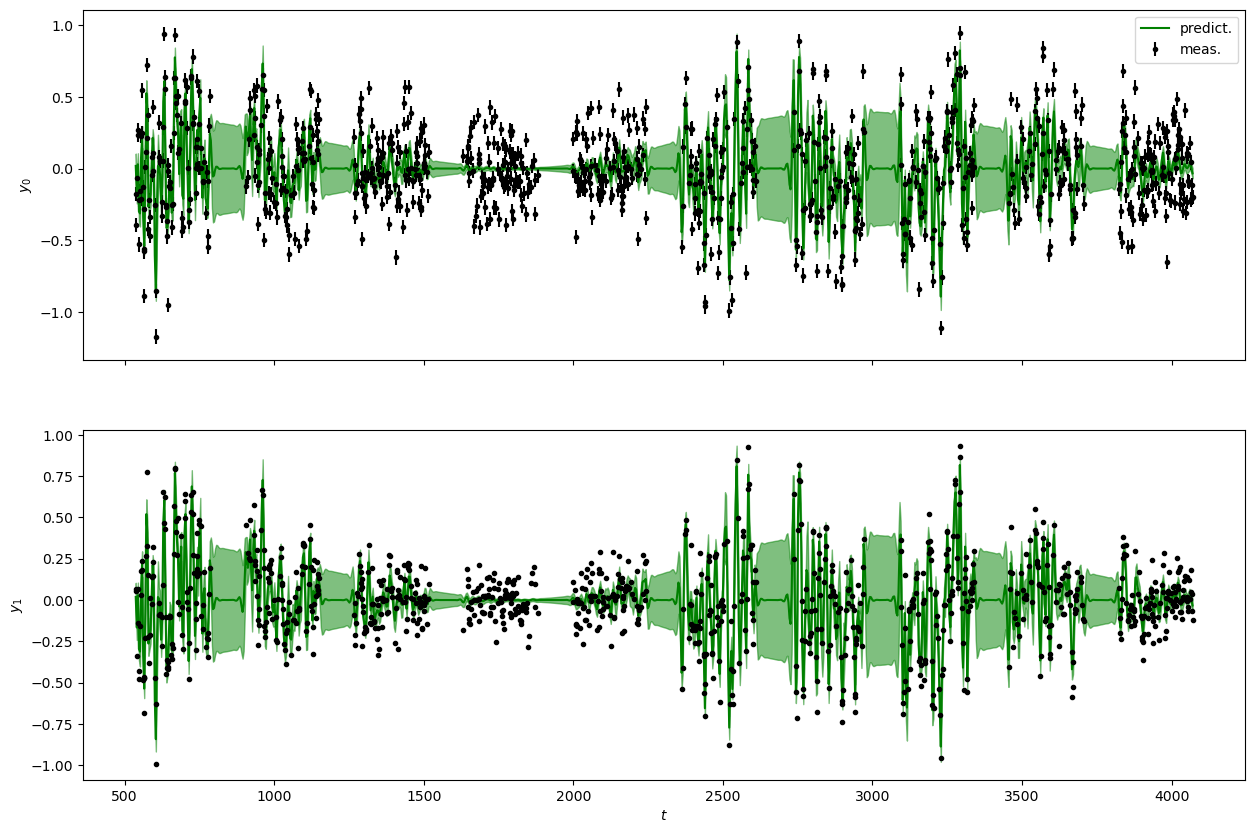

In [53]:
C.set_param(map_sample[:len(params)], params)
# C.set_param([0.0], ['gp.rot_beta_1'])
# C.set_param([np.var(y_full)], ['gp.rot_sig'])


tsmooth = np.linspace(np.min(t_full), np.max(t_full), 1000)
_, axs = plt.subplots(2, 1, sharex=True, figsize=(15, 10))


for k in range(2):
  # Predict time series k
  C.kernel['gp'].set_conditional_coef(series_id=k)
  # C.kernel['rot'].set_conditional_coef(series_id=k)
  # use MAP sample for modulation and offsets
  fc = alpha(t_full, map_sample[2], map_sample[3], map_sample[4],map_sample[5])
  fc_unnorm = (fc - map_sample[5]) / ((1.0 - map_sample[5]) / 2.0) - 1
  y_model = y_full.copy()
  # map_sample tail: [..., gamma_0, gamma_1, delta_0, delta_1]
  y_model[series_index[0]] -= map_sample[-4]*fc_unnorm[series_index[0]] + map_sample[-2]
  y_model[series_index[1]] -= map_sample[-3]*fc_unnorm[series_index[1]] + map_sample[-1]
  mu, var = C.conditional(y_model, tsmooth, calc_cov='diag')
  mu_res, _ = C.conditional(y_model, T[k], calc_cov='diag')
  if k == 0:
    res_rv = Y[k] - mu_res
  else:
    res_rhk = Y[k] - mu_res
  # Plot
  
  ax = axs[k]
  if k ==0 :
    ax.errorbar(T[k], Y[k]-(map_sample[-4]*fc_unnorm[series_index[0]]+map_sample[-2]), Yerr[k], fmt='.', color='k', label='meas.')
  if k == 1:
    ax.errorbar(T[k], Y[k]-(map_sample[-3]*fc_unnorm[series_index[1]]+map_sample[-1]), Yerr[k], fmt='.', color='k', label='meas.')
  ax.fill_between(tsmooth,
    mu - np.sqrt(var),
    mu + np.sqrt(var),
    color='g',
    alpha=0.5)
  ax.plot(tsmooth, mu, 'g', label='predict.')
  ax.set_ylabel(f'$y_{k}$')
ax.set_xlabel('$t$')
axs[0].legend()

plt.show()